<a href="https://colab.research.google.com/github/ncinsli/CLIP-classification-experiments/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### CLIP classification experiments
OpenAI CLIP model is a classification model, which creates multimodal embedding space for images and text labels, allowing user to compare the similarity between them. This notebook is dedicated to different experiments that (maybe) will lead people to better understanding of that model.

#### Imports and constants

In [ ]:
import transformers
import torch
import requests
import torchvision
from torchvision import transforms
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn import metrics, preprocessing
import torch.nn.functional as F
import gc

In [ ]:
BATCH_SIZE = 128
IMAGENETTE_CLASSES = ['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']

#### Model initialization

In [ ]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32", dtype=torch.bfloat16, attn_implementation="sdpa").to('cuda')
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

#### Imagenette dataset initialization

In [96]:
transform = transforms.Compose([
    transforms.PILToTensor(),
])

imagenette_data = torchvision.datasets.Imagenette('imagenette/', download=True, transform=transform)
data_loader = torch.utils.data.DataLoader(imagenette_data,
                                          batch_size=BATCH_SIZE,
                                          shuffle=True,
                                          num_workers=2,
                                          collate_fn=lambda b: ([i[0] for i in b], [i[1] for i in b]))

#### Picking a sample and analyzing CLIP output

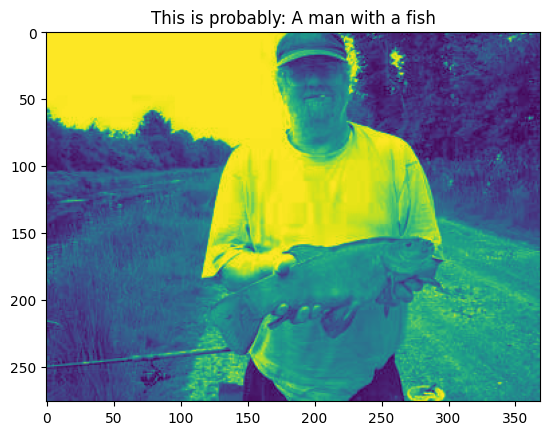

In [103]:
image = data_loader.dataset[128][0]
sample_categories = ['A man with a fish', 'Respectable man', 'Epstein island', 'Well-grown fish']
inputs = processor(text=sample_categories, images=image, padding=True, return_tensors='pt').to('cuda')
outputs = model(**inputs)

plt.title(f'This is probably: {sample_categories[outputs.logits_per_image.argmax(dim=1)]}')
plt.imshow(image[0])


#### Retrieving embeddings manually
Each label we pass to CLIP is processes via CLIPTokenizer and padded to the longest label so we get a list of numbers which have low payload

In [25]:
inputs['input_ids']

tensor([[49406,   320,   786,   593,   320,  2759, 49407],
        [49406,  7466,  2175,   786, 49407, 49407, 49407],
        [49406, 34688,  2619, 49407, 49407, 49407, 49407],
        [49406,  1123,   268,  7120,  2759, 49407, 49407]], device='cuda:0')

In [26]:
model.get_text_features(inputs['input_ids']).pooler_output.detach()

tensor([[-0.1904, -0.0635,  0.0635,  ..., -0.4160, -0.2070, -0.1748],
        [-0.1079,  0.1396,  0.1426,  ..., -0.3945, -0.1118, -0.0544],
        [ 0.2354, -0.2715,  0.2012,  ...,  0.2656, -0.2021, -0.3262],
        [-0.0747, -0.0255,  0.1226,  ..., -0.1167, -0.2773,  0.0347]],
       device='cuda:0', dtype=torch.bfloat16)

#### Evaluating CLIP on Imagenette

In [98]:
correct_classifications = 0
all_classifications = 0
predictions = torch.Tensor([], device='cpu')
truth = torch.Tensor([], device='cpu')

for batch, t in tqdm(data_loader):
  with torch.no_grad():
    inputs = processor(images=batch, text=IMAGENETTE_CLASSES, padding=True, return_tensors='pt').to('cuda')
    outputs = model(**inputs)
    predicted_cat = outputs.logits_per_image.argmax(dim=1).to('cpu')

    batch_truth = torch.Tensor(t).to('cpu')
    predictions = torch.cat((predictions, predicted_cat))
    truth = torch.cat((truth, batch_truth))

    correct_classifications += int((predicted_cat == batch_truth).sum())
    all_classifications += BATCH_SIZE


  0%|          | 0/74 [00:00<?, ?it/s]

<BarContainer object of 10 artists>

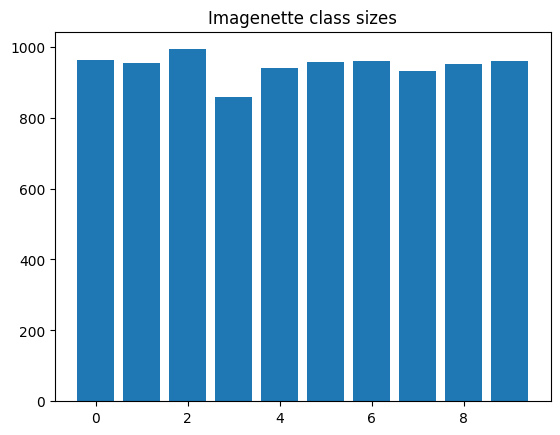

In [ ]:
freqs = Counter(truth.tolist())
plt.title('Imagenette class sizes')
plt.bar(freqs.keys(), freqs.values())

In [42]:
print(f'Accuracy    {metrics.accuracy_score(truth, predictions)}')
print(f'Precision   {metrics.precision_score(truth, predictions, average='macro')}')    # Actually I have no idea in which case we may need micro-averaging.
print(f'Recall      {metrics.recall_score(truth, predictions, average='macro')}')       # The classes are distributed rather equally, so we could use micro,
print(f'F1          {metrics.f1_score(truth, predictions, average='macro')}')           # but macro seems to be at least not worse.

Accuracy    0.9878551061358116
Precision   0.9877990798430517
Recall      0.987710914828965
F1          0.9877173018394961


In [122]:
pure_vit_model = torchvision.models.vit_b_32(weights='IMAGENET1K_V1').to('cuda')

In [124]:
transform_with_resize = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

imagenette_data_uniform = torchvision.datasets.Imagenette('imagenette/', download=True, transform=transform_with_resize)
vit_data_loader = torch.utils.data.DataLoader(imagenette_data_uniform,
                                          batch_size=BATCH_SIZE,
                                          shuffle=True,
                                          num_workers=2)

for batch, t in tqdm(vit_data_loader):
  with torch.no_grad():
    print(batch.dtype)
    result = pure_vit_model.forward(batch.to('cuda'))
    print(result)
    print(result.shape)
    break


  0%|          | 0/74 [00:00<?, ?it/s]

torch.float32
tensor([[-0.4365, -0.0588,  0.0685,  ...,  0.2940,  1.9094,  1.4504],
        [ 0.4649,  0.8010, -0.0503,  ...,  0.0997, -0.3524,  1.0595],
        [ 0.1335, -0.6235,  0.3455,  ...,  0.4078,  0.1902, -0.2720],
        ...,
        [ 0.3551, -0.0046,  0.3768,  ..., -0.6814,  0.6707, -0.8870],
        [-0.1955,  0.5096,  0.2836,  ..., -0.0035, -0.5562,  0.1981],
        [ 0.1553,  1.3426,  1.4903,  ..., -0.3844,  0.1322,  0.9993]],
       device='cuda:0')
torch.Size([128, 1000])
